# Task 1: EDA & Preprocessing — CrediTrust Complaint Data
RAG Complaint Chatbot — Week 7 Challenge

In [5]:
## Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

### Upload CSV File

Run the following cell to upload your CSV file. A file selection dialog will appear after you run it.

In [7]:

!wget --header="bypass-tunnel-reminder: true" -q "[https://YOUR-URL.loca.lt/data](https://YOUR-URL.loca.lt/data)" -O /content/complaints.csv · then pd.read_csv("/content/complaints.csv", low_memory=False) (edited)


'wget' is not recognized as an internal or external command,
operable program or batch file.


What are the Product i have?


In [8]:
print(df['Product'].unique())

NameError: name 'df' is not defined

In [ ]:
print(df.shape)

(396542, 18)


##  Missing Value Analysis

Before any filtering we examine which columns contain missing data. The most critical column is `Consumer complaint narrative` — our main text input for the RAG pipeline. If a complaint has no narrative, it is useless for our system and must be dropped.

In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Missing values:
Date received                        0
Product                              0
Sub-product                          7
Issue                                0
Sub-issue                         4551
Consumer complaint narrative    381447
Company public response         365337
Company                              1
State                              644
ZIP code                             3
Tags                            386153
Consumer consent provided?      355675
Submitted via                        1
Date sent to company                 1
Company response to consumer         1
Timely response?                     1
Consumer disputed? 



I examine which columns contain missing data. The most critical finding is that
`Consumer complaint narrative` has 381,447 missing values out of 396,542 rows —
meaning only ~4% of complaints have a narrative. We will filter to keep only those.

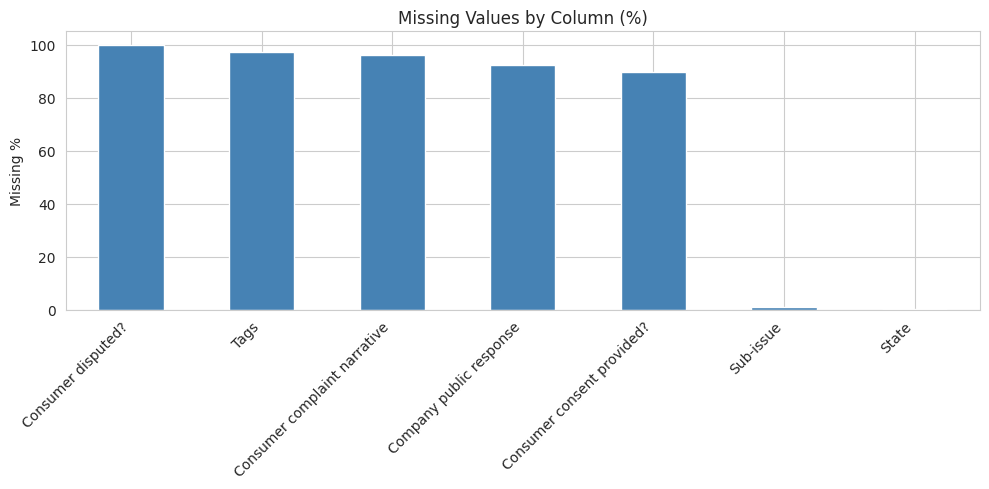

In [ ]:
# Visualize missing values as percentage
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='bar', color='steelblue')
plt.title('Missing Values by Column (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

## Product Distribution

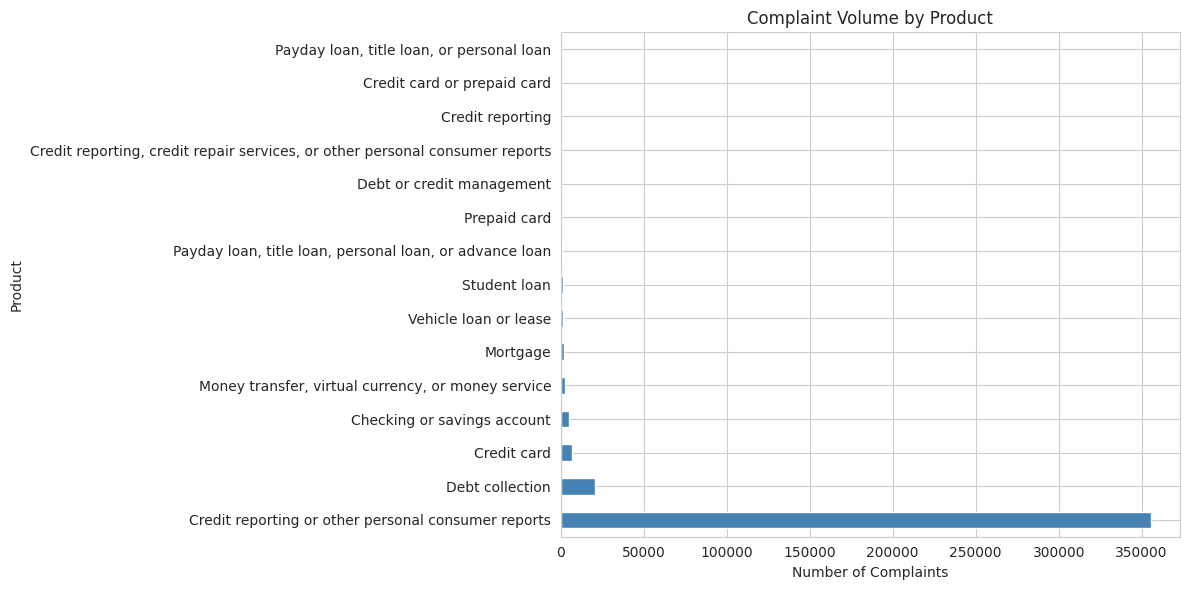


Product counts:
Product
Credit reporting or other personal consumer reports                             355320
Debt collection                                                                  20906
Credit card                                                                       6762
Checking or savings account                                                       4900
Money transfer, virtual currency, or money service                                2281
Mortgage                                                                          1686
Vehicle loan or lease                                                             1523
Student loan                                                                      1519
Payday loan, title loan, personal loan, or advance loan                            901
Prepaid card                                                                       427
Debt or credit management                                                          265
Credit reporting, 

In [ ]:
product_counts = df['Product'].value_counts()

plt.figure(figsize=(12, 6))
product_counts.plot(kind='barh', color='steelblue')
plt.title('Complaint Volume by Product')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('product_distribution.png', dpi=150)
plt.show()

print('\nProduct counts:')
print(product_counts.to_string())

## Product Distribution — Findings

The dataset spans 15 product categories, but volume is heavily skewed: **Credit reporting or other personal consumer reports** accounts for 355,320 of 396,542 complaints (~90%). The remaining categories make up a long tail, with **Debt collection** a distant second (20,906) and the rest under 7,000 each.

This matters for Task 1 filtering — our 4 target products (Credit Card, Personal Loan, Savings Account, Money Transfer) are minority categories in the full dataset, so the filtered set will be small relative to the raw 396,542 rows.





## Narrative Length Analysis

count    15095.000000
mean       186.061477
std        191.803082
min          6.000000
25%         66.000000
50%        137.000000
75%        256.000000
max       5307.000000
Name: Consumer complaint narrative, dtype: float64


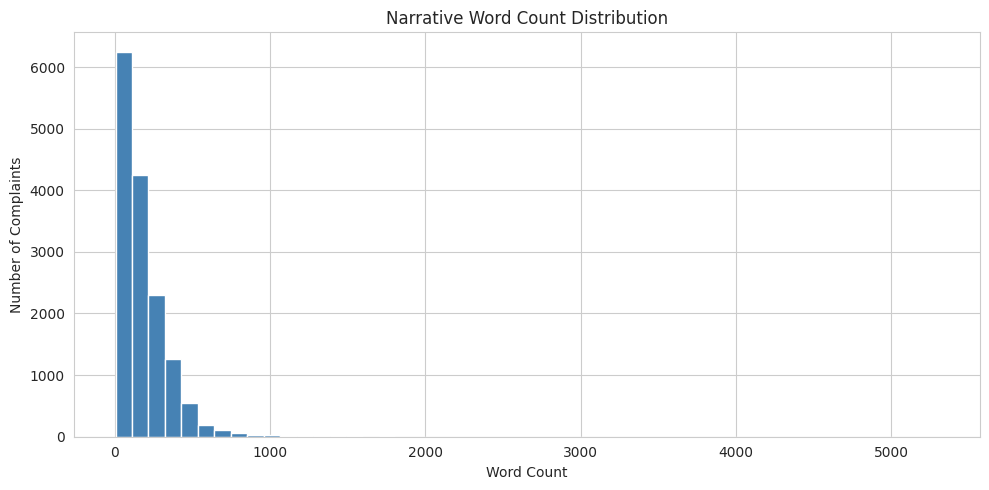

In [ ]:
# Word count per narrative (only rows that have one)
narrative_lengths = df['Consumer complaint narrative'].dropna().str.split().str.len()

print(narrative_lengths.describe())

plt.figure(figsize=(10, 5))
narrative_lengths.hist(bins=50, color='steelblue')
plt.title('Narrative Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('narrative_length.png', dpi=150)
plt.show()

### Narrative Length — Findings

Only **15,095 (3.8%)** of the **396,542** complaints contain a narrative, consistent with the earlier missing-value analysis.

Narrative lengths are **right-skewed**, with a median of **137 words** and a mean of **186 words**, indicating a few very long complaints. Most narratives are under **500 words**, while the longest reaches **5,307 words**.

For Task 2, a **500-character chunk size** should be sufficient, as most narratives will require only **1–3 chunks**.


In [ ]:
## Filter to Target Products

In [ ]:
target_products = [
    'Credit card',
    'Credit card or prepaid card',
    'Payday loan, title loan, personal loan, or advance loan',
    'Payday loan, title loan, or personal loan',
    'Checking or savings account',
    'Money transfer, virtual currency, or money service'
]

filtered_df = df[df['Product'].isin(target_products)].copy()

# Drop checking-account complaints from the combined "Checking or savings account" category
is_checking_savings = filtered_df['Product'] == 'Checking or savings account'
is_checking_subproduct = filtered_df['Sub-product'].str.contains('checking', case=False, na=False)
filtered_df = filtered_df[~(is_checking_savings & is_checking_subproduct)].copy()

filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].notnull()].copy()

print(f"Before filtering: {len(df)}")
print(f"After filtering (target products, savings-only, has narrative): {len(filtered_df)}")
print(filtered_df['Product'].value_counts())

Before filtering: 396542
After filtering (target products, savings-only, has narrative): 1343
Product
Credit card                                                894
Money transfer, virtual currency, or money service         201
Payday loan, title loan, personal loan, or advance loan    123
Checking or savings account                                123
Credit card or prepaid card                                  2
Name: count, dtype: int64


In [ ]:
category_map = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer'
}
filtered_df['product_category'] = filtered_df['Product'].map(category_map)
print(filtered_df['product_category'].value_counts())

product_category
Credit Card        896
Money Transfer     201
Personal Loan      123
Savings Account    123
Name: count, dtype: int64


## Filtering — Findings

After restricting to the 4 target products and dropping rows without a narrative, we're left with **1,343 complaints** out of 396,542 — about 0.3% of the raw data. This is expected: narratives are rare overall (3.8%), and our 4 target products are a small slice of total volume to begin with.

Class balance by category:
- Credit Card: **896**
- Money Transfer: **201**
- Personal Loan: **123**
- Savings Account: **123**

Credit Card dominates the filtered set, while Personal Loan and Savings Account are much smaller. This imbalance is noted for the Task 2 stratified sample, where Personal Loan and Savings Account will remain minority classes regardless of sampling method.

## Clean Narrative Text

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'i am writing to file a complaint', '', text)
    text = re.sub(r'x{2,}', '', text)          # redacted placeholders like XXXX
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # strip special chars
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)
filtered_df[['Consumer complaint narrative', 'cleaned_narrative']].head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...
14249,"Although the account had been deemed closed, I...",although the account had been deemed closed i ...


## Check for Byte-String Artifacts

In [ ]:
byte_artifact_mask = filtered_df['Consumer complaint narrative'].str.match(r"^b['\"]")
print(f"Rows with byte-string artifact: {byte_artifact_mask.sum()}")
filtered_df[byte_artifact_mask][['Consumer complaint narrative']].head()

Rows with byte-string artifact: 10


,Consumer complaint narrative
13955,b'I am writing to dispute the following charge...
64787,"b""We called Macy's XXXX XXXX XXXX and told the..."
130757,b'Home Depot credit Services received a paymen...
142278,b'I chat with automatic system chat service XX...
160818,"b""On XXXX XXXX XXXX I received my monthly stat..."


# Byte-string artifacts found; fixing in clean_text before re-running.

## Fix Byte-String Artifact + Re-clean

In [ ]:
def clean_text(text):
    text = re.sub(r"^b['\"]", '', text)
    text = re.sub(r"['\"]$", '', text)
    text = text.lower()
    text = re.sub(r'i am writing to file a complaint', '', text)
    text = re.sub(r'x{2,}', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)

byte_artifact_mask = filtered_df['Consumer complaint narrative'].str.match(r"^b['\"]")
filtered_df[byte_artifact_mask][['Consumer complaint narrative', 'cleaned_narrative']]

,Consumer complaint narrative,cleaned_narrative
13955,b'I am writing to dispute the following charge...,i am writing to dispute the following charges ...
64787,"b""We called Macy's XXXX XXXX XXXX and told the...",we called macy s and told the operated that we...
130757,b'Home Depot credit Services received a paymen...,home depot credit services received a payment ...
142278,b'I chat with automatic system chat service XX...,i chat with automatic system chat service on o...
160818,"b""On XXXX XXXX XXXX I received my monthly stat...",on i received my monthly statement from citi b...
249176,b'Hi Officer. \nMy partner used my name and So...,hi officer nmy partner used my name and social...
288984,"b'On XXXX XXXX XXXX, I lawfully submitted a ne...",on i lawfully submitted a negotiable instrumen...
308426,b'OXXXX XXXX XXXX we deposited a check from XX...,o we deposited a check from in the amount of t...
318865,"b""I applied for a Wells Fargo credit card on X...",i applied for a wells fargo credit card on for...
356439,b'On XXXX XXXX Wells Fargo contacted my spouse...,on wells fargo contacted my spouse to inform u...


## Byte-String Fix — Confirmed

Byte-string artifacts removed from all affected rows. A second issue was found: literal `\n` newline characters were merging into words (e.g. "date" + newline + "amount" → "datenamount"). Fixed in the same cleaning step.

In [ ]:
def clean_text(text):
    text = re.sub(r"^b['\"]", '', text)
    text = re.sub(r"['\"]$", '', text)
    text = text.replace('\\n', ' ').replace('\n', ' ')
    text = text.lower()
    text = re.sub(r'i am writing to file a complaint', '', text)
    text = re.sub(r'x{2,}', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)
newline_mask = filtered_df['Consumer complaint narrative'].str.contains(r'\\n', regex=True, na=False)
filtered_df[newline_mask][['Consumer complaint narrative', 'cleaned_narrative']].head()

,Consumer complaint narrative,cleaned_narrative
13955,b'I am writing to dispute the following charge...,i am writing to dispute the following charges ...
65986,bXXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX ...,b re did not disclose the annual fee of 125 00...
249176,b'Hi Officer. \nMy partner used my name and So...,hi officer my partner used my name and social ...
288984,"b'On XXXX XXXX XXXX, I lawfully submitted a ne...",on i lawfully submitted a negotiable instrumen...
356439,b'On XXXX XXXX Wells Fargo contacted my spouse...,on wells fargo contacted my spouse to inform u...


## Save Filtered & Cleaned Dataset

In [ ]:
os.makedirs('data/processed', exist_ok=True)
filtered_df.to_csv('data/processed/filtered_complaints.csv', index=False)
print(f"Saved {len(filtered_df)} rows to data/processed/filtered_complaints.csv")
filtered_df[['Product', 'cleaned_narrative']].sample(5, random_state=1)

Saved 1343 rows to data/processed/filtered_complaints.csv


,Product,cleaned_narrative
280113,Credit card,this is for a card with sheels fnbo i received...
93033,"Payday loan, title loan, personal loan, or adv...",on i had a with one of my pets i did not have ...
347129,Credit card,i received a notification from wells fargo on ...
341818,Checking or savings account,i have been receiving the 4 interest rate but ...
118530,Credit card,i am being charged over and over for a late fe...


## Task 1 Complete

Filtered, cleaned dataset saved: **1,343 rows** across 4 target categories (Credit Card, Money Transfer, Personal Loan, Savings Account). EDA findings documented (missing values, product distribution, narrative length). Notebook ready for commit.